In [ ]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

## 1. Imports and Model Loading

In [1]:
import os
import sys
import gc
import uuid

import imageio
import numpy as np
import torch
from IPython.display import Image as ImageDisplay

ROOT = os.path.abspath("..")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from inference_new import (
    Inference,
    ready_gaussian_for_video_rendering,
    load_image,
    load_masks,
    display_image,
    make_scene,
    render_video,
    interactive_visualizer,
)

2026-04-30 14:38:08.267 | INFO     | sam3d_objects.pipeline.inference_pipeline_new:set_attention_backend:19 - GPU name is NVIDIA GeForce RTX 5060 Ti
2026-04-30 14:38:08.742 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.sparse:__from_env:39 - [SPARSE] Backend: spconv, Attention: sdpa


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/home/user/.local/share/mamba/envs/sam3d_128/lib/python3.11/site-packages/spconv/pytorch/functional.py:47: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  _TORCH_CUSTOM_FWD = amp.custom_fwd(cast_inputs=torch.float16)
/home/user/.local/share/mamba/envs/sam3d_128/lib/python3.11/site-packages/spconv/pytorch/functional.py:96: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @_TORCH_CUSTOM_BWD
/home/user/.local/share/mamba/envs/sam3d_128/lib/python3.11/site-packages/spconv/pytorch/functional.py:162: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @_TORCH_CUSTOM_BWD
/home/user/.local/share/mamba/envs/sam3d_128/lib/python3.11/site-packages/spconv/pytorch/functional.py:242: FutureWarning: `torch.cuda.amp.custom_bwd(args.

[SPARSE][CONV] spconv algo: auto


2026-04-30 14:38:11.545 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-04-30 14:38:11.546 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 


In [2]:
PATH = os.getcwd()
TAG = "hf"
config_path = f"{PATH}/../checkpoints/{TAG}/pipeline.yaml"

inference = Inference(config_path, compile=False)

2026-04-30 14:38:18.744 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
/home/user/.local/share/mamba/envs/sam3d_128/lib/python3.11/site-packages/moge/model/v1.py:171: UserWarning: The following deprecated/invalid arguments are ignored: {'output_mask': True, 'split_head': True}
  warnings.warn(f"The following deprecated/invalid arguments are ignored: {deprecated_kwargs}")
2026-04-30 14:38:21.522 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-04-30 14:38:22.207 | INFO     | sam3d_objects.pipeline.inference_pipeline_new:__init__:104 - self.device: cuda
2026-04-30 14:38:22.208 | INFO     | sam3d_objects.pipeline.inference_pipeline_new:__init__:105 - CUDA_VISIBLE_DEVICES: None
2026-04-30 14:38:22.208 | INFO     | sam3d_objects.pipeline.inference_pipeline_new:__init__:106 - Actually using GPU: 0
2026-04-30 14:38:2

## 2. Load Input Image and Masks

Loaded 2 masks from /home/user/Desktop/sam-3d-objects_NEW/notebook/images/kid_box


/home/user/Desktop/sam-3d-objects_NEW/notebook/inference_new.py:415: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


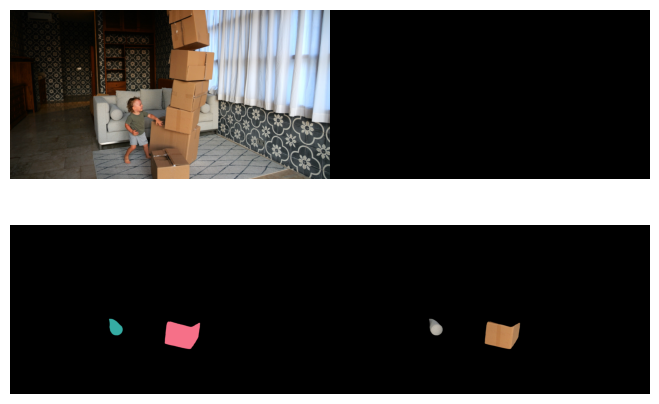

In [ ]:
# Multi-object inference needs one mask file per object: 0.png, 1.png, 2.png, ...
IMAGE_DIR = f"{PATH}/images/kid_box"
IMAGE_PATH = f"{IMAGE_DIR}/image.png"
IMAGE_NAME = os.path.basename(IMAGE_DIR)

image = load_image(IMAGE_PATH)

# Use a small subset first because each mask runs a full inference pass.
# Set MASK_INDICES = None to run every contiguous mask in IMAGE_DIR.
MASK_INDICES = [0, 1,2]
masks = load_masks(IMAGE_DIR, indices_list=MASK_INDICES, extension=".png")
print(f"Loaded {len(masks)} masks from {IMAGE_DIR}")

display_image(image, masks)

## 3. Generate Gaussian Splats

In [4]:
outputs = []

for idx, mask in enumerate(masks):
    print(f"Running object {idx + 1}/{len(masks)}")
    output = inference(image, mask, seed=42)
    outputs.append(output)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

len(outputs)

2026-04-30 14:38:49.579 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap_new:depth_model_context:129 - Loading Stage 1 MoGe model to cuda...


Running object 1/2


2026-04-30 14:38:50.078 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap_new:depth_model_context:135 - Releasing Stage 1 MoGe model from VRAM...
2026-04-30 14:38:51.473 | INFO     | sam3d_objects.pipeline.inference_pipeline_new:stage_model_context:269 - Loading Stage 2 sparse structure models to cuda...
2026-04-30 14:38:51.562 | INFO     | sam3d_objects.model.io:load_model_from_checkpoint:158 - Loading checkpoint from /home/user/Desktop/sam-3d-objects_NEW/notebook/../checkpoints/hf/ss_generator.ckpt
2026-04-30 14:38:56.309 | INFO     | sam3d_objects.pipeline.inference_pipeline_new:override_ss_generator_cfg_config:509 - ss_generator parameters: inference_steps=25, cfg_strength=7, cfg_interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-04-30 14:38:56.316 | INFO     | sam3d_objects.model.io:load_model_from_checkpoint:158 - Loading checkpoint from /home/user/Desktop/sam-3d-objects_NEW/notebook/../checkpoints/hf/ss_decoder.ckpt
2026-04-30 14:38:56.477 | INFO     | sam3d_

Running object 2/2


2026-04-30 14:40:27.915 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap_new:depth_model_context:135 - Releasing Stage 1 MoGe model from VRAM...
2026-04-30 14:40:28.660 | INFO     | sam3d_objects.pipeline.inference_pipeline_new:stage_model_context:269 - Loading Stage 2 sparse structure models to cuda...
2026-04-30 14:40:28.724 | INFO     | sam3d_objects.model.io:load_model_from_checkpoint:158 - Loading checkpoint from /home/user/Desktop/sam-3d-objects_NEW/notebook/../checkpoints/hf/ss_generator.ckpt
2026-04-30 14:40:32.049 | INFO     | sam3d_objects.pipeline.inference_pipeline_new:override_ss_generator_cfg_config:509 - ss_generator parameters: inference_steps=25, cfg_strength=7, cfg_interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-04-30 14:40:32.055 | INFO     | sam3d_objects.model.io:load_model_from_checkpoint:158 - Loading checkpoint from /home/user/Desktop/sam-3d-objects_NEW/notebook/../checkpoints/hf/ss_decoder.ckpt
2026-04-30 14:40:32.148 | INFO     | sam3d_

2

## 4. Save and Render Multi-Object Scene

In [5]:
multi_dir = f"{PATH}/gaussians/multi"
os.makedirs(multi_dir, exist_ok=True)

scene_gs = make_scene(*outputs)
scene_gs.save_ply(f"{multi_dir}/{IMAGE_NAME}_posed.ply")

scene_gs = ready_gaussian_for_video_rendering(scene_gs)
scene_gs.save_ply(f"{multi_dir}/{IMAGE_NAME}.ply")

video = render_video(
    scene_gs,
    r=1,
    fov=60,
    pitch_deg=15,
    yaw_start_deg=-45,
    resolution=512,
)["color"]

gif_path = f"{multi_dir}/{IMAGE_NAME}.gif"
imageio.mimsave(
    gif_path,
    video,
    format="GIF",
    duration=1000 / 30,
    loop=0,
)

ImageDisplay(url=f"gaussians/multi/{IMAGE_NAME}.gif?cache_invalidator={uuid.uuid4()}")

Rendering: 300it [00:02, 101.67it/s]


## 5. Interactive Visualizer

In [ ]:
# might take a while to load (black screen)
interactive_visualizer(f"{PATH}/gaussians/multi/{IMAGE_NAME}.ply")